# Exploratory analysis

EDA only: the pipeline itself lives in `sql/` and `src/carbon_forecast/`. This notebook reads the DuckDB database built by `make all` and looks at the patterns that motivated the feature design.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from carbon_forecast.config import load_settings, resolve
from carbon_forecast.evaluate import MODELS, _style

_style()
con = duckdb.connect(str(resolve(load_settings()["db_path"])), read_only=True)
BLUE, ORANGE, AQUA, YELLOW = (
    MODELS[m][1]
    for m in ("weather_forecast", "no_weather", "seasonal_naive_day", "seasonal_naive_week")
)

## 1. Long-run level: intensity has fallen since 2019

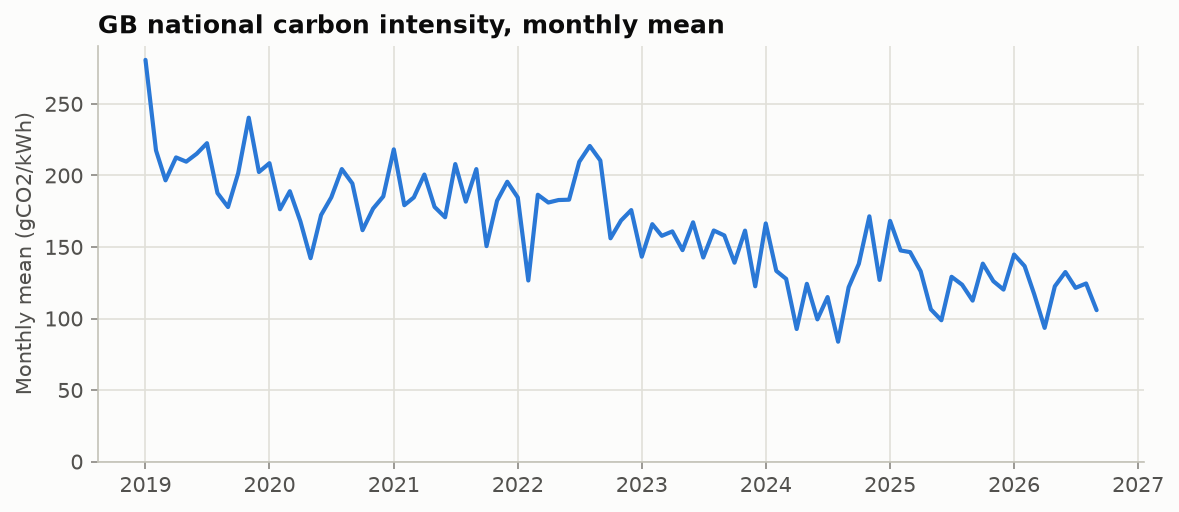

,year,mean_gco2,half_hours
0,2019,214.0,17212
1,2020,180.3,17484
2,2021,187.8,17332
3,2022,182.5,17469
4,2023,152.2,17419
5,2024,125.1,17537
6,2025,129.2,17520
7,2026,122.2,12959


In [2]:
monthly = con.sql("""
    SELECT date_trunc('month', period_start_utc) AS month, avg(actual_gco2) AS mean_gco2
    FROM stg_intensity GROUP BY 1 ORDER BY 1
""").df()
yearly = con.sql("""
    SELECT year(period_start_utc) AS year, round(avg(actual_gco2), 1) AS mean_gco2,
           count(actual_gco2) AS half_hours
    FROM stg_intensity WHERE period_start_utc >= TIMESTAMP '2019-01-01'
    GROUP BY 1 ORDER BY 1
""").df()
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(monthly["month"], monthly["mean_gco2"], color=BLUE)
ax.set_ylabel("Monthly mean (gCO2/kWh)")
ax.set_title("GB national carbon intensity, monthly mean")
ax.set_ylim(bottom=0)
plt.show()
yearly

The annual mean fell by roughly 40% between 2019 and 2024 and has been flat since (table above). A model trained on the early years sees a higher level than the test period, which is why the no-weather model's forecasts are biased upwards in the backtest, and why recent-level features such as the 7-day mean matter.

## 2. Daily shape by season

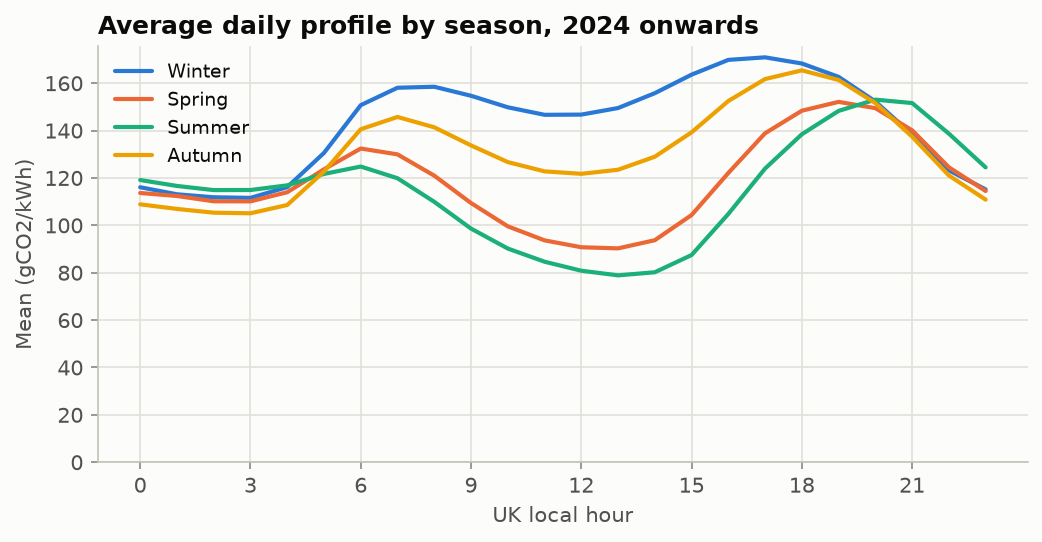

season,Autumn,Spring,Summer,Winter
hour,,,,
0.0,109.0,114.0,119.0,116.0
3.0,105.0,110.0,115.0,112.0
6.0,141.0,132.0,125.0,151.0
9.0,134.0,109.0,99.0,155.0
12.0,122.0,91.0,81.0,147.0
15.0,139.0,104.0,87.0,164.0
18.0,165.0,148.0,138.0,168.0
21.0,137.0,140.0,152.0,138.0


In [3]:
profile = con.sql("""
    SELECT CASE WHEN c.month IN (12, 1, 2) THEN 'Winter' WHEN c.month IN (3, 4, 5) THEN 'Spring'
                WHEN c.month IN (6, 7, 8) THEN 'Summer' ELSE 'Autumn' END AS season,
           floor(c.local_hour) AS hour, avg(i.actual_gco2) AS mean_gco2
    FROM calendar c JOIN stg_intensity i USING (period_start_utc)
    WHERE c.period_start_utc >= TIMESTAMP '2024-01-01'
    GROUP BY ALL ORDER BY season, hour
""").df()
fig, ax = plt.subplots(figsize=(8, 3.6))
for season, col in zip(
    ["Winter", "Spring", "Summer", "Autumn"], [BLUE, ORANGE, AQUA, YELLOW], strict=True
):
    g = profile[profile["season"] == season]
    ax.plot(g["hour"], g["mean_gco2"], color=col, label=season)
ax.set_xlabel("UK local hour")
ax.set_ylabel("Mean (gCO2/kWh)")
ax.set_title("Average daily profile by season, 2024 onwards")
ax.set_xticks(range(0, 24, 3))
ax.set_ylim(bottom=0)
ax.legend()
plt.show()
profile.pivot(index="hour", columns="season", values="mean_gco2").round(0).iloc[::3]

Every season has an evening peak, and summer has a deep midday dip as solar output peaks. The shape depends on both time of day and season, so the model gets the target's settlement period, local hour and day of year rather than a single seasonal lag.

## 3. Wind share drives most of the variation

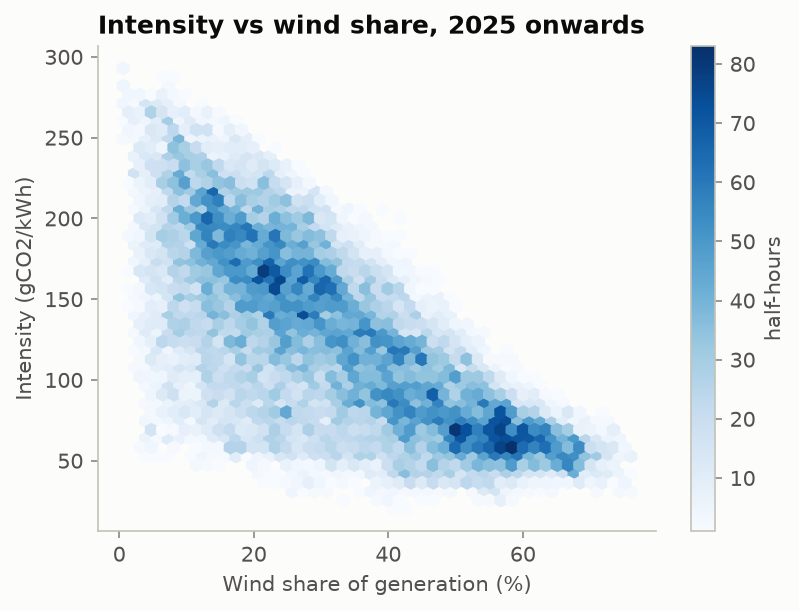

,actual_gco2
wind_pct,-0.704
solar_pct,-0.321
gas_pct,0.979


In [4]:
mix = con.sql("""
    SELECT i.actual_gco2, g.wind_pct, g.solar_pct, g.gas_pct
    FROM stg_intensity i JOIN stg_generation g USING (period_start_utc)
    WHERE i.period_start_utc >= TIMESTAMP '2025-01-01' AND i.actual_gco2 IS NOT NULL
""").df()
fig, ax = plt.subplots(figsize=(6, 4.2))
hb = ax.hexbin(mix["wind_pct"], mix["actual_gco2"], gridsize=45, cmap="Blues", mincnt=1)
ax.set_xlabel("Wind share of generation (%)")
ax.set_ylabel("Intensity (gCO2/kWh)")
ax.set_title("Intensity vs wind share, 2025 onwards")
ax.grid(False)
fig.colorbar(hb, ax=ax, label="half-hours")
plt.show()
mix.corr().loc[["wind_pct", "solar_pct", "gas_pct"], ["actual_gco2"]].round(3)

Intensity is almost a linear function of the gas share (correlation shown above), and gas fills whatever wind and solar do not. Forecasting intensity a day ahead is therefore largely forecasting wind and solar output, which is why weather forecasts are the most valuable input.

## 4. How much does the past tell us? Autocorrelation by lag

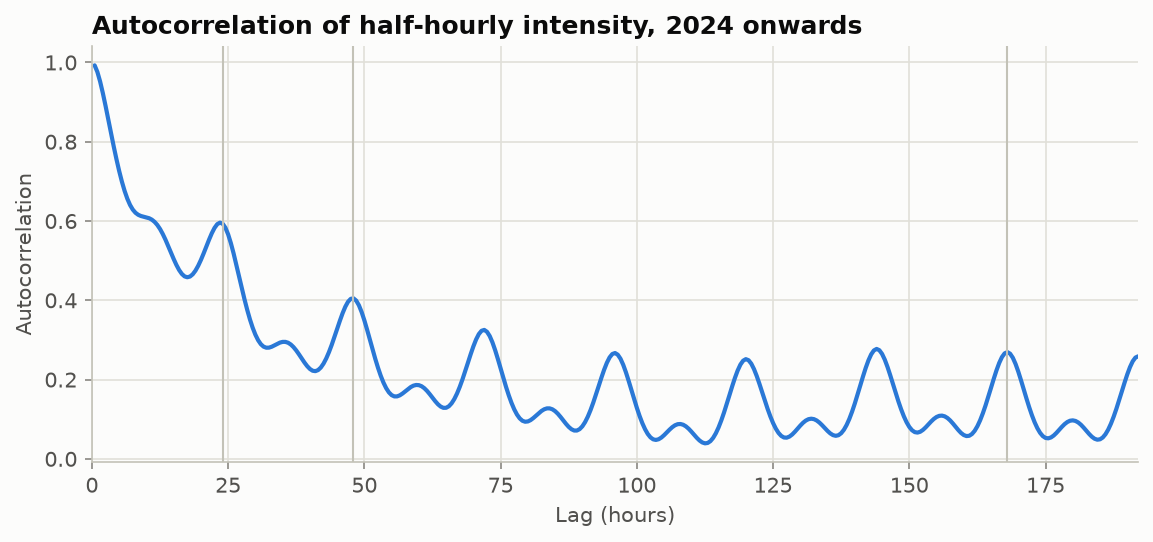

1h      0.976
6h      0.676
24h     0.593
48h     0.405
72h     0.325
168h    0.269
Name: autocorrelation, dtype: float64

In [5]:
series = (
    con.sql("""
    SELECT c.period_start_utc, i.actual_gco2
    FROM calendar c LEFT JOIN stg_intensity i USING (period_start_utc)
    WHERE c.period_start_utc >= TIMESTAMP '2024-01-01'
      AND c.period_start_utc <= (SELECT max(period_start_utc) FROM stg_intensity)
    ORDER BY 1
""")
    .df()
    .set_index("period_start_utc")["actual_gco2"]
)
lags_h = np.arange(0.5, 24 * 8 + 0.5, 0.5)
acf = [series.autocorr(int(h * 2)) for h in lags_h]
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(lags_h, acf, color=BLUE)
for h in (24, 48, 168):
    ax.axvline(h, color="#c3c2b7", linewidth=1)
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Autocorrelation")
ax.set_title("Autocorrelation of half-hourly intensity, 2024 onwards")
ax.set_xlim(0, 24 * 8)
plt.show()
pd.Series(
    {f"{h}h": round(series.autocorr(h * 2), 3) for h in (1, 6, 24, 48, 72, 168)},
    name="autocorrelation",
)

Correlation with the recent past is very high at an hour, falls to moderate values by 24 hours and lower still by 48 hours. Peaks at every multiple of 24 hours show a clear daily cycle, but they shrink as the lag grows. History alone therefore offers limited skill at a day-ahead horizon, which matches the weak persistence and seasonal naive baselines, while the daily cycle justifies the seasonal lag features.

## 5. Are day-ahead weather forecasts good enough to use?

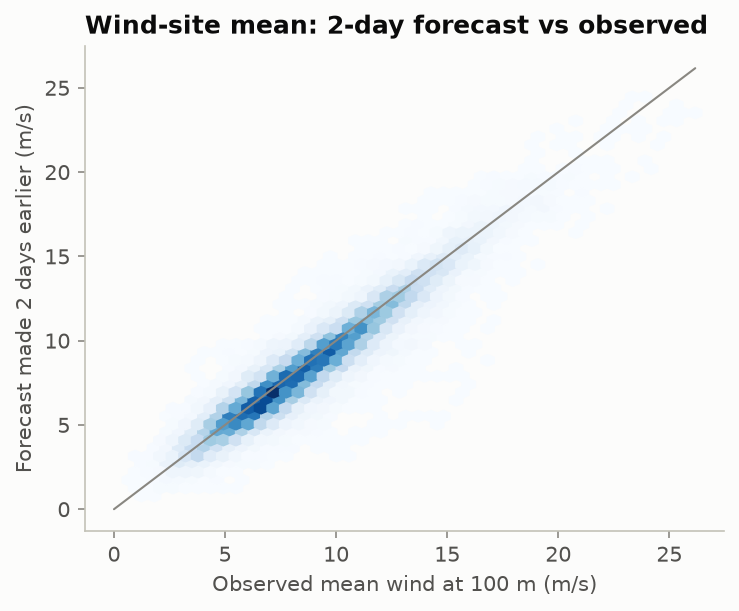

,hours,corr,mae_ms
lead_days,,,
1,44782.0,0.973,0.603
2,44782.0,0.943,0.841
3,44782.0,0.895,1.145


In [6]:
wx = con.sql("""
    SELECT f.period_start_utc, f.lead_days, f.wind_speed_100m_mean AS forecast,
           o.wind_speed_100m_mean AS observed
    FROM feat_weather f JOIN feat_weather o
      ON o.period_start_utc = f.period_start_utc AND o.lead_days = 0
    WHERE f.lead_days > 0
""").df()
fig, ax = plt.subplots(figsize=(5.5, 4.2))
g = wx[wx["lead_days"] == 2]
ax.hexbin(g["observed"], g["forecast"], gridsize=45, cmap="Blues", mincnt=1)
lim = [0, max(g["observed"].max(), g["forecast"].max())]
ax.plot(lim, lim, color="#898781", linewidth=1)
ax.set_xlabel("Observed mean wind at 100 m (m/s)")
ax.set_ylabel("Forecast made 2 days earlier (m/s)")
ax.set_title("Wind-site mean: 2-day forecast vs observed")
ax.grid(False)
plt.show()
wx.groupby("lead_days").apply(
    lambda d: pd.Series(
        {
            "hours": len(d),
            "corr": d["forecast"].corr(d["observed"]),
            "mae_ms": (d["forecast"] - d["observed"]).abs().mean(),
        }
    ),
    include_groups=False,
).round(3)

Forecast skill for wind declines with lead time (table above). The model has to use day-3 forecasts beyond about 40 hours ahead, because day-2 forecasts for those hours were not yet available when the forecast was issued, and this is where its error steps up in the backtest.